
---

### **TÂCHE 4 — Créer le notebook "02_analyse_prix.ipynb"**

```markdown
# NOTEBOOK 02 — ANALYSE DES PRIX IMMOBILIERS

## Objectif
Ce notebook présente les analyses statistiques et graphiques des prix immobiliers à Dakar et au Sénégal.

## 1. Import des librairies
```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import scipy.stats as stats

# - 2. Chargement des données nettoyées

In [66]:
df = pd.read_csv("expat_dakar_pieces_traite.csv", encoding='utf-8-sig')
print(f"Nombre d'annonces : {len(df)}")

Nombre d'annonces : 4313


# - 3. Distribution des prix

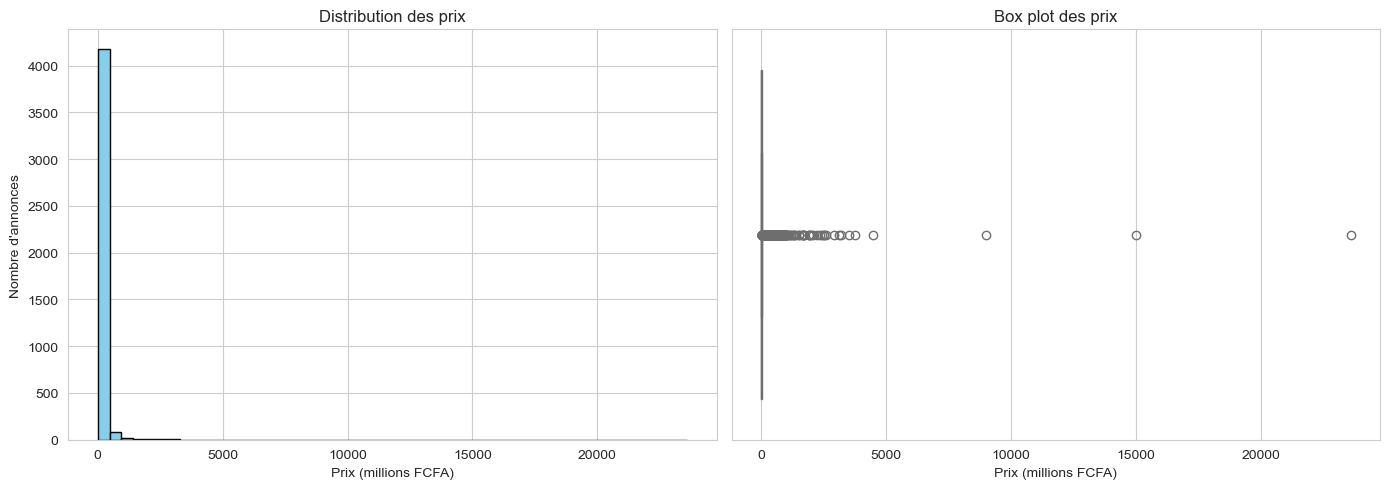

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
axes[0].hist(df['prix_fcfa'].dropna() / 1_000_000, bins=50, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Prix (millions FCFA)')
axes[0].set_ylabel("Nombre d'annonces")
axes[0].set_title('Distribution des prix')

# Box plot
sns.boxplot(x=df['prix_fcfa'] / 1_000_000, ax=axes[1], color='lightcoral')
axes[1].set_xlabel('Prix (millions FCFA)')
axes[1].set_title('Box plot des prix')

plt.tight_layout()
plt.savefig('distribution_prix_globale.png')
plt.show()

# - 4. Prix moyen par quartier (Top 20)

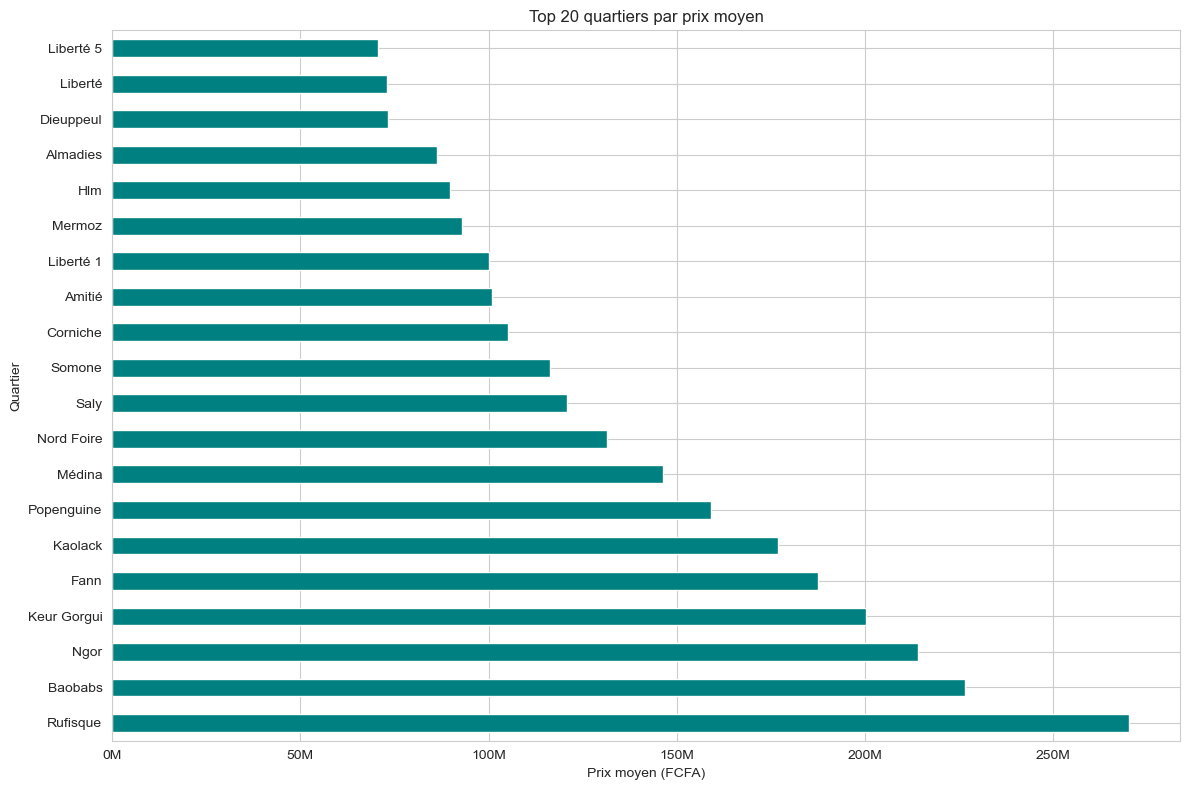

In [68]:
prix_quartier = df.groupby('quartier')['prix_fcfa'].mean().dropna().sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 8))
prix_quartier.plot(kind='barh', color='teal')
plt.xlabel('Prix moyen (FCFA)')
plt.ylabel('Quartier')
plt.title('Top 20 quartiers par prix moyen')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1_000_000:.0f}M'))
plt.tight_layout()
plt.savefig('prix_moyen_quartier_top20.png')
plt.show()

# - 5. Évolution temporelle des prix

  ÉVOLUTION TEMPORELLE DES PRIX
  Démarrage: 2026-03-13 02:59:48

📂 4313 annonces chargées
📊 4310 annonces avec année et mois valides

📈 APERÇU DE L'ÉVOLUTION (derniers mois) :
date
2025-04-01    1.119974e+08
2025-05-01    4.775735e+07
2025-06-01    4.854525e+07
2025-07-01    8.518503e+07
2025-08-01    5.325094e+07
2025-09-01    5.408336e+07
2025-10-01    5.834098e+07
2025-11-01    1.452936e+08
2025-12-01    6.643523e+07
2026-01-01    8.047471e+07
2026-02-01    6.549374e+07
2026-03-01    5.436924e+07
Name: prix_fcfa, dtype: float64


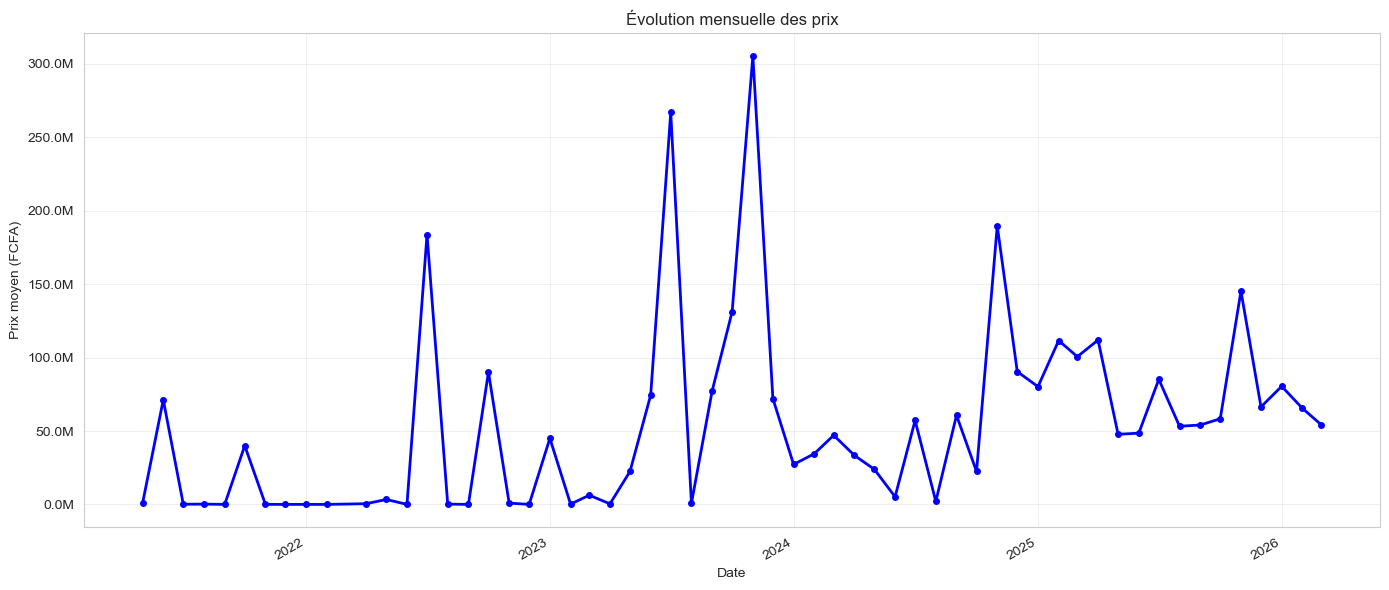


✅ Graphique sauvegardé : evolution_temporelle_prix.png

  Fin: 2026-03-13 02:59:49


In [71]:
# ============================================
# TÂCHE 4 — ÉVOLUTION TEMPORELLE DES PRIX (CORRIGÉ)
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

print("="*65)
print("  ÉVOLUTION TEMPORELLE DES PRIX")
print("="*65)
print(f"  Démarrage: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# Chargement des données
df = pd.read_csv("expat_dakar_pieces_traite.csv", encoding='utf-8-sig')
print(f"\n📂 {len(df)} annonces chargées")

# Solution : filtrer les NaN avant conversion
df_temp = df.dropna(subset=['annee_pub', 'mois_pub']).copy()
print(f"📊 {len(df_temp)} annonces avec année et mois valides")

# Conversion en entiers
df_temp['annee_pub'] = df_temp['annee_pub'].astype(int)
df_temp['mois_pub'] = df_temp['mois_pub'].astype(int)

# Création de la colonne date
df_temp['date'] = pd.to_datetime(
    df_temp['annee_pub'].astype(str) + '-' + 
    df_temp['mois_pub'].astype(str) + '-01'
)

# ✅ UTILISER df_temp pour le groupby (pas df)
evolution = df_temp.groupby('date')['prix_fcfa'].mean()

print(f"\n📈 APERÇU DE L'ÉVOLUTION (derniers mois) :")
print(evolution.tail(12))

# Création du graphique
plt.figure(figsize=(14, 6))
evolution.plot(marker='o', linestyle='-', color='blue', linewidth=2, markersize=4)
plt.xlabel('Date')
plt.ylabel('Prix moyen (FCFA)')
plt.title('Évolution mensuelle des prix')
plt.grid(True, alpha=0.3)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1_000_000:.1f}M'))
plt.tight_layout()
plt.savefig('evolution_temporelle_prix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Graphique sauvegardé : evolution_temporelle_prix.png")
print(f"\n  Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# - notebook2 suite

  NOTEBOOK 02 — ANALYSE DES PRIX (SUITE)
  Démarrage: 2026-03-13 03:06:17

📂 4313 annonces chargées

  6. PRIX PAR TYPE DE BIEN

📊 STATISTIQUES PAR TYPE DE BIEN :
                    mean       median  count
type_simple                                 
Vente        245917779.0  110000000.0   1337
Location       2040875.0     727500.0   2216
Autre           966144.0      45000.0    760

💾 Tableau sauvegardé : statistiques_par_type_bien.csv


C:\Users\Dell\AppData\Local\Temp\ipykernel_9100\614847644.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='type_simple', y=df['prix_fcfa'] / 1_000_000, ax=axes[0], palette='Set2')


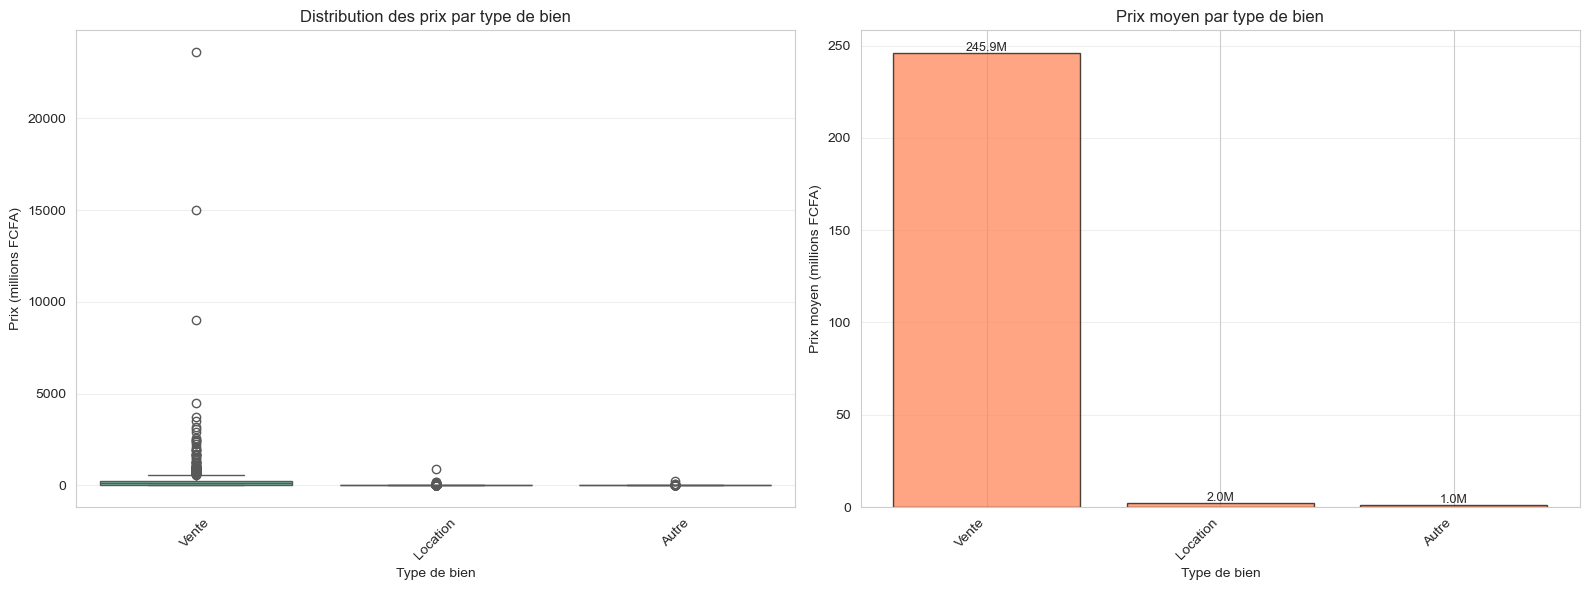


✅ Graphique sauvegardé : prix_par_type_bien.png

  7. CORRÉLATION PRIX / SURFACE
📊 1381 annonces avec surface et prix renseignés

📊 ANALYSE DE CORRÉLATION :
   Corrélation de Pearson    : r = 0.193 (p-value = 5.271e-13)
   Corrélation de Spearman   : ρ = 0.277 (p-value = 8.295e-26)


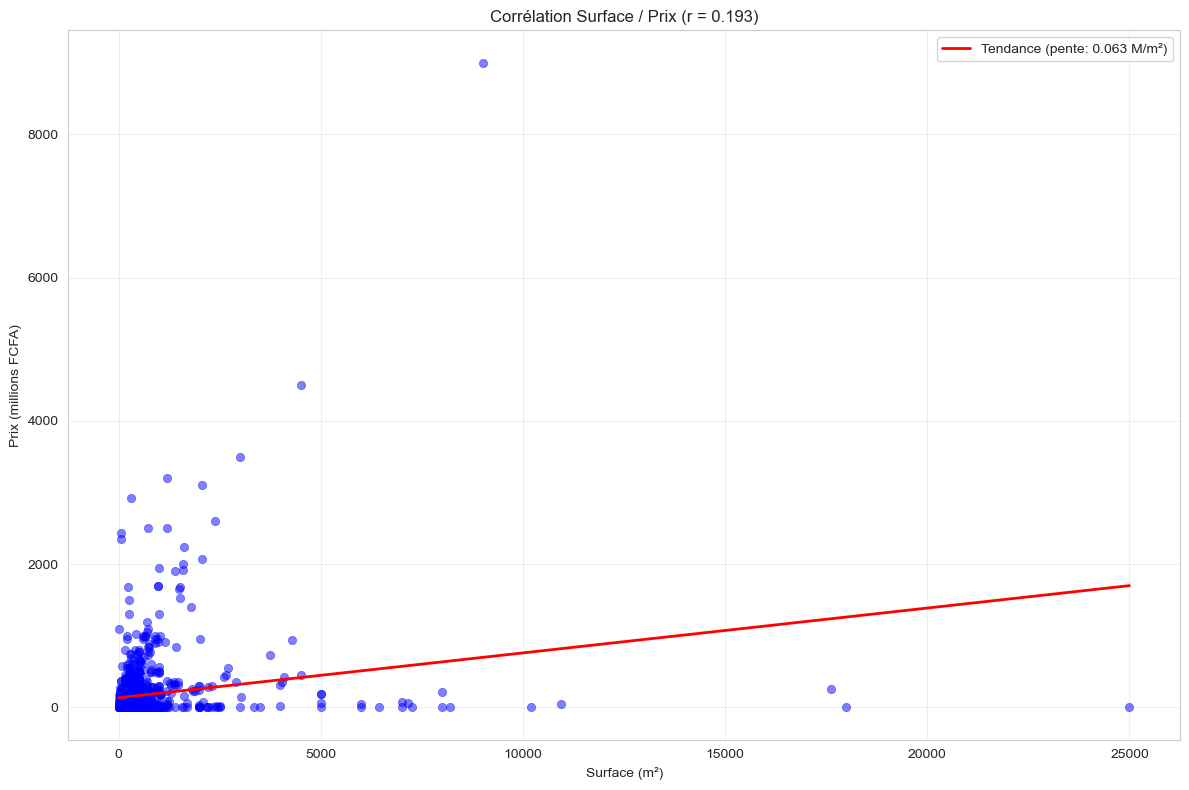


✅ Graphique sauvegardé : correlation_prix_surface.png

  8. RÉSUMÉ DES INDICATEURS CLÉS

=== INDICATEURS CLÉS ===
📊 PRIX :
   Prix moyen   : 77,451,639 FCFA
   Prix médian  : 1,000,000 FCFA
   Prix min     : 1 FCFA
   Prix max     : 23,600,000,000 FCFA

📍 QUARTIERS :
   Quartier le plus cher      : Rufisque (270,154,737 FCFA)
   Quartier le plus accessible : Tambacounda (27,500 FCFA)

📈 ÉVOLUTION :
   Évolution mensuelle moyenne : 24459.3%
   Plus forte hausse           : 714551.4%
   Plus forte baisse           : -99.9%

🏠 TYPES DE BIEN :
   Vente        : 1337 annonces, prix moyen 245.9M FCFA
   Location     : 2216 annonces, prix moyen 2.0M FCFA
   Autre        :  760 annonces, prix moyen 1.0M FCFA

  Fin: 2026-03-13 03:06:19


In [73]:
# ============================================
# NOTEBOOK 02 — ANALYSE DES PRIX (SUITE)
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from datetime import datetime

print("="*65)
print("  NOTEBOOK 02 — ANALYSE DES PRIX (SUITE)")
print("="*65)
print(f"  Démarrage: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# Chargement des données (si pas déjà fait)
df = pd.read_csv("expat_dakar_pieces_traite.csv", encoding='utf-8-sig')
print(f"\n📂 {len(df)} annonces chargées")

# ============================================
# 6. PRIX PAR TYPE DE BIEN
# ============================================

print("\n" + "="*65)
print("  6. PRIX PAR TYPE DE BIEN")
print("="*65)

# Création de la colonne type_simple (si pas déjà fait)
def categoriser_type(x):
    x_str = str(x).lower() if pd.notna(x) else ''
    if 'louer' in x_str or 'location' in x_str:
        return 'Location'
    elif 'vendre' in x_str or 'vente' in x_str:
        return 'Vente'
    elif 'terrain' in x_str:
        return 'Terrain'
    elif 'commercial' in x_str:
        return 'Commercial'
    else:
        return 'Autre'

df['type_simple'] = df['categorie'].apply(categoriser_type)

# Statistiques par type
stats_type = df.groupby('type_simple')['prix_fcfa'].agg(['mean', 'median', 'count']).round(0)
stats_type = stats_type.sort_values('mean', ascending=False)
print(f"\n📊 STATISTIQUES PAR TYPE DE BIEN :")
print(stats_type.to_string())

# Sauvegarde en CSV
stats_type.to_csv('statistiques_par_type_bien.csv')
print(f"\n💾 Tableau sauvegardé : statistiques_par_type_bien.csv")

# Création du graphique
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot par type
sns.boxplot(data=df, x='type_simple', y=df['prix_fcfa'] / 1_000_000, ax=axes[0], palette='Set2')
axes[0].set_xlabel('Type de bien')
axes[0].set_ylabel('Prix (millions FCFA)')
axes[0].set_title('Distribution des prix par type de bien')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Prix moyen par type
prix_type = df.groupby('type_simple')['prix_fcfa'].mean().sort_values(ascending=False)
bars = axes[1].bar(range(len(prix_type)), prix_type.values / 1_000_000, 
                   color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xticks(range(len(prix_type)))
axes[1].set_xticklabels(prix_type.index, rotation=45, ha='right')
axes[1].set_xlabel('Type de bien')
axes[1].set_ylabel('Prix moyen (millions FCFA)')
axes[1].set_title('Prix moyen par type de bien')
axes[1].grid(True, alpha=0.3, axis='y')

# Ajouter les valeurs sur les barres
for i, (bar, val) in enumerate(zip(bars, prix_type.values)):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                 f'{val/1_000_000:.1f}M', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('prix_par_type_bien.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Graphique sauvegardé : prix_par_type_bien.png")

# ============================================
# 7. CORRÉLATION PRIX / SURFACE
# ============================================

print("\n" + "="*65)
print("  7. CORRÉLATION PRIX / SURFACE")
print("="*65)

# Filtrer les annonces avec surface et prix valides
df_corr = df.dropna(subset=['prix_fcfa', 'surface_m2']).copy()
print(f"📊 {len(df_corr)} annonces avec surface et prix renseignés")

# Calcul de la corrélation
corr, p_value = stats.pearsonr(df_corr['surface_m2'], df_corr['prix_fcfa'])
corr_spearman, p_value_spearman = stats.spearmanr(df_corr['surface_m2'], df_corr['prix_fcfa'])

print(f"\n📊 ANALYSE DE CORRÉLATION :")
print(f"   Corrélation de Pearson    : r = {corr:.3f} (p-value = {p_value:.3e})")
print(f"   Corrélation de Spearman   : ρ = {corr_spearman:.3f} (p-value = {p_value_spearman:.3e})")

# Création du graphique
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_corr, x='surface_m2', y=df_corr['prix_fcfa'] / 1_000_000, 
                alpha=0.5, color='blue', edgecolor=None)
plt.xlabel('Surface (m²)')
plt.ylabel('Prix (millions FCFA)')
plt.title(f'Corrélation Surface / Prix (r = {corr:.3f})')
plt.grid(True, alpha=0.3)

# Ajouter une ligne de régression
z = np.polyfit(df_corr['surface_m2'], df_corr['prix_fcfa'], 1)
p = np.poly1d(z)
x_sorted = np.sort(df_corr['surface_m2'])
plt.plot(x_sorted, p(x_sorted) / 1_000_000, 'r-', linewidth=2, 
         label=f'Tendance (pente: {z[0]/1_000_000:.3f} M/m²)')
plt.legend()

plt.tight_layout()
plt.savefig('correlation_prix_surface.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Graphique sauvegardé : correlation_prix_surface.png")

# ============================================
# 8. RÉSUMÉ DES INDICATEURS CLÉS
# ============================================

print("\n" + "="*65)
print("  8. RÉSUMÉ DES INDICATEURS CLÉS")
print("="*65)

# Prix moyen par quartier (calculé précédemment)
prix_quartier = df.groupby('quartier')['prix_fcfa'].mean().dropna().sort_values(ascending=False)

# Évolution mensuelle (calculée précédemment)
df_temp = df.dropna(subset=['annee_pub', 'mois_pub']).copy()
df_temp['annee_pub'] = df_temp['annee_pub'].astype(int)
df_temp['mois_pub'] = df_temp['mois_pub'].astype(int)
df_temp['date'] = pd.to_datetime(
    df_temp['annee_pub'].astype(str) + '-' + 
    df_temp['mois_pub'].astype(str) + '-01'
)
evolution = df_temp.groupby('date')['prix_fcfa'].mean()

print("\n=== INDICATEURS CLÉS ===")
print(f"📊 PRIX :")
print(f"   Prix moyen   : {df['prix_fcfa'].mean():,.0f} FCFA")
print(f"   Prix médian  : {df['prix_fcfa'].median():,.0f} FCFA")
print(f"   Prix min     : {df['prix_fcfa'].min():,.0f} FCFA")
print(f"   Prix max     : {df['prix_fcfa'].max():,.0f} FCFA")

print(f"\n📍 QUARTIERS :")
if len(prix_quartier) > 0:
    print(f"   Quartier le plus cher      : {prix_quartier.index[0]} ({prix_quartier.values[0]:,.0f} FCFA)")
    print(f"   Quartier le plus accessible : {prix_quartier.index[-1]} ({prix_quartier.values[-1]:,.0f} FCFA)")

print(f"\n📈 ÉVOLUTION :")
print(f"   Évolution mensuelle moyenne : {evolution.pct_change().mean():.1%}")
print(f"   Plus forte hausse           : {evolution.pct_change().max():.1%}")
print(f"   Plus forte baisse           : {evolution.pct_change().min():.1%}")

print(f"\n🏠 TYPES DE BIEN :")
for type_bien in stats_type.index:
    print(f"   {type_bien:<12} : {stats_type.loc[type_bien, 'count']:>4} annonces, "
          f"prix moyen {stats_type.loc[type_bien, 'mean']/1_000_000:.1f}M FCFA")

print(f"\n  Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# - 

# - 